In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import networkx as nx
from statsmodels.nonparametric.smoothers_lowess import lowess

In [30]:

# reading the qc file 
qc_mixed_data = pd.read_excel(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\mix_biorep\qc_mixed.xlsx",
    sheet_name=0,
    header=12
)

print(qc_mixed_data.head())

   Peak    tR1    tR2     tR  m/z                                 ID Names  \
0     1  1.924  2.096  2.024   64   1.627%    3072   64   48   69  55   64   
1     2  2.186  2.299  2.240   58   9.885%    2494   43   58   42  37   58   
2     3  2.180  2.293  2.258   72   3.195%    3024   72   42   41  42   72   
3     4  2.282  2.379  2.326   79   5.403%    3397   43   79   74  29   79   
4     5  2.420  2.579  2.480   60  10.067%    2700   60   45   42  47   60   

   s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  \
0               155776               197632               235392   
1               408408               501312               431743   
2               194496               191168               166464   
3               269252               339499               530167   
4               283468               650674               684636   

   s4 S96_QC4_B1_D1_T1  ...  s71 S96_QC3_B2_D19_T1  s72 S96_QC4_B2_D19_T1  \
0               174656  ...                 2

# Since T1 and T2 were the repeated experiments and the peaks have overlap I just used T1.

In [31]:
# Clean column names (remove spaces)
qc_mixed_data.columns = qc_mixed_data.columns.str.strip()

# consider Metadata columns
metadata_cols = ['Peak', 'tR1', 'tR2', 'tR', 'm/z']

# Select columns that end with "T1"
t1_cols = [c for c in qc_mixed_data.columns if c.strip().endswith("T1")]

# Combine metadata + T1 columns
qc_data_T1 = qc_mixed_data[metadata_cols + t1_cols]

# Show results
print("Selected T1 sample columns:")
print(t1_cols)
print("\nFiltered DataFrame shape:", qc_data_T1.shape)
print(qc_data_T1.head())

Selected T1 sample columns:
['s1 S96_QC1_B1_D1_T1', 's2 S96_QC2_B1_D1_T1', 's3 S96_QC3_B1_D1_T1', 's4 S96_QC4_B1_D1_T1', 's5 S96_QC1_B1_D2_T1', 's6 S96_QC2_B1_D2_T1', 's7 S96_QC3_B1_D2_T1', 's8 S96_QC4_B1_D2_T1', 's9 S96_QC1_B1_D3_T1', 's10 S96_QC2_B1_D3_T1', 's11 S96_QC3_B1_D3_T1', 's12 S96_QC4_B1_D3_T1', 's13 S96_QC2_B1_D4_T1', 's14 S96_QC3_B1_D4_T1', 's15 S96_QC4_B1_D4_T1', 's16 S96_QC1_B1_D4_T1', 's17 S96_QC1_B1_D5_T1', 's18 S96_QC1_B1_D9_T1', 's19 S96_QC2_B1_D5_T1', 's20 S96_QC2_B1_D9_T1', 's21 S96_QC3_B1_D5_T1', 's22 S96_QC3_B1_D9_T1', 's23 S96_QC4_B1_D5_T1', 's24 S96_QC4_B1_D9_T1', 's25 S96_QC1_B1_D10_T1', 's26 S96_QC1_B1_D6_T1', 's27 S96_QC1_B1_D7_T1', 's28 S96_QC1_B1_D8_T1', 's29 S96_QC3_B1_D10_T1', 's30 S96_QC3_B1_D6_T1', 's31 S96_QC3_B1_D7_T1', 's32 S96_QC4_B1_D10_T1', 's33 S96_QC4_B1_D6_T1', 's34 S96_QC4_B1_D7_T1', 's35 S96_QC2_B1_D8_T1', 's36 S96_QC3_B1_D8_T1', 's37 S96_QC4_B1_D8_T1', 's38 S96_QC1_B2_D11_T1', 's39 S96_QC2_B2_D11_T1', 's40 S96_QC4_B2_D11_T1', 's41 S96_QC3_B

In [32]:
# we got the information of qcdata to see more details qc data inlcudes four qc including QC1, QC2, QC3 and QC4
qc_data_T1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 85 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Peak                   194 non-null    int64  
 1   tR1                    194 non-null    float64
 2   tR2                    194 non-null    float64
 3   tR                     194 non-null    float64
 4   m/z                    194 non-null    int64  
 5   s1 S96_QC1_B1_D1_T1    194 non-null    int64  
 6   s2 S96_QC2_B1_D1_T1    194 non-null    int64  
 7   s3 S96_QC3_B1_D1_T1    194 non-null    int64  
 8   s4 S96_QC4_B1_D1_T1    194 non-null    int64  
 9   s5 S96_QC1_B1_D2_T1    194 non-null    int64  
 10  s6 S96_QC2_B1_D2_T1    194 non-null    int64  
 11  s7 S96_QC3_B1_D2_T1    194 non-null    int64  
 12  s8 S96_QC4_B1_D2_T1    194 non-null    int64  
 13  s9 S96_QC1_B1_D3_T1    194 non-null    int64  
 14  s10 S96_QC2_B1_D3_T1   194 non-null    int64  
 15  s11 S9

In [33]:

# Since we had three retention time in our qc data derived from msmetrix ,  we got differences between retention time beacuse we want to have just one retention time
diff_t_vs_1 = (qc_data_T1['tR'] -qc_data_T1['tR1']).abs()
diff_t_vs_2 = (qc_data_T1['tR'] - qc_data_T1['tR2']).abs()
diff_1_vs_2 = (qc_data_T1['tR1'] -qc_data_T1['tR2']).abs()
avg_t   = (qc_data_T1['tR1'] + qc_data_T1['tR2']) / 2
diff_avg_vs_t = (avg_t - qc_data_T1['tR']).abs()

# printing the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    194.000000
mean       0.031253
std        0.016083
min        0.013000
25%        0.020000
50%        0.026000
75%        0.036750
max        0.100000
dtype: float64 

abs(tR - tR2):
 count    194.000000
mean       0.032871
std        0.016166
min        0.013000
25%        0.022000
50%        0.027000
75%        0.039000
max        0.099000
dtype: float64 

abs(tR1 - tR2):
 count    194.000000
mean       0.064124
std        0.028307
min        0.027000
25%        0.044000
50%        0.055000
75%        0.079750
max        0.186000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    194.000000
mean       0.005351
std        0.005618
min        0.000000
25%        0.001000
50%        0.003000
75%        0.007875
max        0.027000
dtype: float64 



The two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.

In [34]:
# put TR as tR_best instead of other tr
qc_data_T1['tR_best'] = (qc_data_T1['tR1'] + qc_data_T1['tR2']) / 2

# removing unnecessary columns
to_keep = [col for col in qc_data_T1.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_qc = qc_data_T1[to_keep]

# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_qc.columns)

cols = cleaned_qc.columns.tolist()
# Moving 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_qc = cleaned_qc[cols]
# Check the result
print(cleaned_qc.head())
# Save cleaned data with tR_best
cleaned_qc.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_qc.csv", index=False)
# now this cleaned_qc datafram can be used for further analysis

tR_best column saved: True
   Peak  tR_best  m/z  s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  \
0     1   2.0100   64               155776               197632   
1     2   2.2425   58               408408               501312   
2     3   2.2365   72               194496               191168   
3     4   2.3305   79               269252               339499   
4     5   2.4995   60               283468               650674   

   s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  \
0               235392               174656               157632   
1               431743               175808              1140423   
2               166464               183095               212416   
3               530167               502473               314171   
4               684636               491963               387257   

   s6 S96_QC2_B1_D2_T1  s7 S96_QC3_B1_D2_T1  ...  s71 S96_QC3_B2_D19_T1  \
0               184192               172736  ...                 218936   
1          

# Preparing the samples derived by MS-metrix after GC-MS


In [ ]:


# Biorep1
input_path1 = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\final_sample_1-10.xlsx"
df_raw1 = pd.read_excel(input_path1, header=None)
header_row1 = df_raw1[df_raw1.iloc[:, 0].astype(str).str.strip() == "Peak"].index[0]
rep1 = pd.read_excel(input_path1, header=header_row1)

# Biorep2
input_path2 = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\biorep2_sample.xlsx"
df_raw2 = pd.read_excel(input_path2, header=None)
header_row2 = df_raw2[df_raw2.iloc[:, 0].astype(str).str.strip() == "Peak"].index[0]
rep2 = pd.read_excel(input_path2, header=header_row2)

print("Rep1 shape:", rep1.shape)
print("Rep2 shape:", rep2.shape)
print(rep1.head())
print(rep2.head())


Rep1 shape: (602, 192)
Rep2 shape: (229, 192)
   Peak    tR1    tR2     tR  m/z  \
0     1  1.859  1.953  1.906   40   
1     2  1.923  2.006  1.964   44   
2     3  1.948  2.047  1.998   64   
3     4  1.951  2.113  2.032   41   
4     5  2.016  2.084  2.050   47   

                                            ID Names  s1 S96_44_B1_D1_T1  \
0    0.16%  || 40                                ...               10596   
1    2.35%  || 44   81  169  119                 ...              903226   
2   13.68%  || 64  42  48  40  38  37  66  50  36...             3756487   
3    9.68%  || 41  39  69  65                    ...             2953729   
4    0.60%  || 47  56  77  49                    ...              105215   

   s2 S96_14_B1_D1_T1  s3 S96_9_B1_D1_T1  s4 S96_28_B1_D1_T1  ...  \
0               20120              16056               19568  ...   
1               76330              77813              831144  ...   
2             2936231            1910915             2419738  ...  

In [ ]:


print("Rep1 shape:", rep1.shape)
print("Rep2 shape:", rep2.shape)

#  Rename sample columns to distinguish reps 
rep1 = rep1.rename(columns={c: f"{c}_Rep1" for c in rep1.columns if str(c).startswith("s")})
rep2 = rep2.rename(columns={c: f"{c}_Rep2" for c in rep2.columns if str(c).startswith("s")})

#  Matching tolerance
tR_tol, mz_tol = 0.05, 0.5
rt_col, mz_col = "tR", "m/z"

# Match peaks 
matched_rows = []
for _, row1 in rep1.iterrows():
    tr1, mz1 = row1[rt_col], row1[mz_col]
    candidates = rep2[(np.abs(rep2[rt_col] - tr1) <= tR_tol) &
                      (np.abs(rep2[mz_col] - mz1) <= mz_tol)]

    if not candidates.empty:
        j = candidates.iloc[(candidates[rt_col] - tr1).abs().argmin()]
        merged = pd.concat([row1, j.drop(["Peak", rt_col, mz_col])]).to_dict()
    else:
        merged = row1.to_dict()
    matched_rows.append(merged)

# Convert to DataFrame
df_matched = pd.DataFrame(matched_rows)

print("Merged shape:", df_matched.shape)

# Save merged table
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\merged_bioreps.xlsx"
df_matched.to_excel(output_path, index=False)
print(f" Merged table saved: {output_path}")
# Convert to DataFrame
df_matched

Rep1 shape: (602, 192)
Rep2 shape: (229, 192)
Merged shape: (602, 378)
 Merged table saved: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\merged_bioreps.xlsx


,Peak,tR1,tR2,tR,m/z,ID Names,s1 S96_44_B1_D1_T1_Rep1,s2 S96_14_B1_D1_T1_Rep1,s3 S96_9_B1_D1_T1_Rep1,s4 S96_28_B1_D1_T1_Rep1,...,s177 S96_24_B2_D14_T1_Rep2,s178 S96_3_B2_D11_T2_Rep2,s179 S96_33_B2_D11_T2_Rep2,s180 S96_43_B2_D18_T1_Rep2,s181 S96_5_B2_D11_T1_Rep2,s182 S96_5_B2_D11_T2_Rep2,s183 S96_7_B2_D18_T1_Rep2,s184 S96_79_B2_D14_T1_Rep2,s185 S96_79_B2_D14_T2_Rep2,s186 S96_82_B2_D18_T1_Rep2
0,1,1.859,1.953,1.906,40,0.16% || 40 ...,10596,20120,16056,19568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1.923,2.006,1.964,44,2.35% || 44 81 169 119 ...,903226,76330,77813,831144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1.934,2.060,1.998,64,6.714% 2624 64 41 42 63 64,3756487,2936231,1910915,2419738,...,919877.0,693810.0,760658.0,539584.0,607601.0,681514.0,716308.0,667367.0,1096704.0,277120.0
3,4,1.951,2.113,2.032,41,9.68% || 41 39 69 65 ...,2953729,3238443,963411,1335012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2.016,2.084,2.050,47,0.60% || 47 56 77 49 ...,105215,81277,109088,188441,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,598,23.188,23.325,23.257,220,0.07% || 220 ...,1657,1456,1323,1189,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
598,599,23.204,23.417,23.311,57,0.29% || 57 205 99 ...,66476,75423,5901,95817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
599,600,23.212,23.473,23.342,191,0.25% || 191 ...,9096,7481,1834,4020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
600,601,23.301,23.459,23.380,105,0.28% || 105 189 192 ...,11853,9576,3921,6922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# Define columns
rt_col, mz_col, id_col = "tR", "m/z", "ID Names"
intensity_cols1 = [c for c in rep1.columns if c.startswith("s")]
intensity_cols2 = [c for c in rep2.columns if c.startswith("s")]

# Match peaks by tR and m/z tolerance 
tR_tol = 0.05   # retention time tolerance
mz_tol = 0.5    # m/z tolerance

matched_rows = []
for i, row1 in rep1.iterrows():
    tr1, mz1 = row1[rt_col], row1[mz_col]
    candidates = rep2[
        (np.abs(rep2[rt_col] - tr1) <= tR_tol) &
        (np.abs(rep2[mz_col] - mz1) <= mz_tol)
    ]
    if not candidates.empty:
        row2 = candidates.iloc[0]  # pick first match if multiple
        merged = pd.concat([
            row1[intensity_cols1].astype(float).rename(lambda x: f"{x}_Rep1"),
            row2[intensity_cols2].astype(float).rename(lambda x: f"{x}_Rep2")
        ])
        # 
        merged["Peak"] = row1["Peak"]          
        merged["Peak Rep1"] = row1["Peak"]     # QC-check
        merged["Peak Rep2"] = row2["Peak"]     # QC-check
        merged["tR"] = tr1
        merged["m/z"] = mz1
        merged["ID Rep1"] = row1[id_col]
        merged["ID Rep2"] = row2[id_col]
    
        matched_rows.append(merged)

# Build DataFrame of matched peaks
df_matched = pd.DataFrame(matched_rows).reset_index(drop=True)

print("Matched shape:", df_matched.shape)

# Save filtered matched peaks 
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\matched_peaks.xlsx"
df_matched.to_excel(output_path, index=False)
print("Filtered table saved to:", output_path)

df_matched.head(10)


Rep1 shape: (602, 192)
Rep2 shape: (229, 192)
Matched shape: (111, 379)
Filtered table saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\matched_peaks.xlsx


,s1 S96_44_B1_D1_T1_Rep1,s2 S96_14_B1_D1_T1_Rep1,s3 S96_9_B1_D1_T1_Rep1,s4 S96_28_B1_D1_T1_Rep1,s5 S96_92_B1_D1_T1_Rep1,s6 S96_21_B1_D1_T1_Rep1,s7 S96_53_B1_D1_T1_Rep1,s8 S96_55_B1_D1_T1_Rep1,s9 S96_44_B1_D1_T2_Rep1,s10 S96_55_B1_D1_T2_Rep1,...,s184 S96_79_B2_D14_T1_Rep2,s185 S96_79_B2_D14_T2_Rep2,s186 S96_82_B2_D18_T1_Rep2,Peak,Peak Rep1,Peak Rep2,tR,m/z,ID Rep1,ID Rep2
0,3756487.0,2936231.0,1910915.0,2419738.0,4436911.0,2329038.0,3388076.0,2776992.0,4520484.0,2024862.0,...,667367.0,1096704.0,277120.0,3.0,3.0,1.0,1.998,64.0,13.68% || 64 42 48 40 38 37 66 50 36...,6.714% 2624 64 41 42 63 64
1,23781704.0,22422855.0,20839349.0,21350981.0,20956413.0,20850199.0,20008556.0,19181152.0,22821392.0,18914242.0,...,2804735.0,4025565.0,1847768.0,7.0,7.0,2.0,2.170,45.0,79.18% || 45 43 58 41 42 59 39 46 57...,27.625% 1935 45 43 42 80 45
2,825140.0,1074918.0,1323521.0,1542417.0,979103.0,1022325.0,1374342.0,2887087.0,950732.0,2663017.0,...,148499.0,213370.0,163584.0,11.0,11.0,3.0,2.253,79.0,3.99% || 79 62 52 47 74 61 64 ...,1.492% 4661 79 59 53 26 79
3,900843.0,1220075.0,2221331.0,3094806.0,1685253.0,3287833.0,2239690.0,2721916.0,1029645.0,2655106.0,...,429308.0,482182.0,54505.0,13.0,13.0,4.0,2.350,72.0,6.74% || 72 41 75 73 77 89 90 ...,8.852% 3096 43 72 41 29 72
4,658911.0,556926.0,937777.0,865865.0,952833.0,1224404.0,893914.0,1399069.0,465166.0,1295951.0,...,469952.0,519552.0,221952.0,16.0,16.0,7.0,2.453,86.0,4.61% || 86 42 55 47 40 38 54 37 88...,6.831% 1935 43 45 60 173 86
5,656317.0,305218.0,404108.0,345874.0,332416.0,406940.0,302593.0,724378.0,655983.0,742845.0,...,326730.0,963499.0,224912.0,22.0,22.0,8.0,2.625,132.0,5.08% || 132 82 81 53 63 133 112 ...,7.543% 10692 132 81 63 105 132
6,1174384.0,2150131.0,3550658.0,5878318.0,4081626.0,9374392.0,2956166.0,3949707.0,874796.0,3787369.0,...,784168.0,866600.0,235368.0,27.0,27.0,9.0,2.890,44.0,16.19% || 44 58 43 71 39 57 42 45 86...,32.015% 2552 44 58 41 21 44
7,2569627.0,3363989.0,4533285.0,5347953.0,5396079.0,8668862.0,4196669.0,5108156.0,3379686.0,4385281.0,...,1610776.0,2932992.0,4442851.0,29.0,29.0,10.0,2.978,78.0,32.09% || 78 57 58 77 39 52 51 ...,29.009% 6006 78 77 52 26 78
8,192680.0,111652.0,144696.0,164208.0,144136.0,320229.0,151823.0,208175.0,209069.0,166360.0,...,90104.0,126432.0,79448.0,36.0,36.0,12.0,3.199,57.0,2.05% || 57 43 56 55 41 73 71 84 99...,0.967% 2451 43 57 74 43 57
9,133851.0,53949.0,268058.0,359438.0,297166.0,521017.0,291009.0,448530.0,209979.0,113953.0,...,50741.0,44984.0,120720.0,58.0,58.0,16.0,4.258,117.0,1.51% || 117 89 88 87 58 59 118 ...,1.681% 10413 117 89 88 43 117


# Peak detection for qc data(compound identification)

In [38]:

alkanes = pd.DataFrame([
    {'Compound': 'Octane',      'tR': 5.34},
    {'Compound': 'Decane',      'tR': 10.154},
    {'Compound': 'Dodecane',    'tR': 13.626},
    {'Compound': 'Tetradecane', 'tR': 16.388},
    {'Compound': 'Pentadecane', 'tR': 17.62},
    {'Compound': 'Octadecane',  'tR': 20.906},
    {'Compound': 'Eicosane',    'tR': 22.825},
])

# define tolerance windows 
rt_tol = 0.05   # retention time tolerance
mz_tol = 0.1    # m/z tolerance

matches = []
for _, alk in alkanes.iterrows():
    sub = cleaned_qc[
        (cleaned_qc["m/z"].between(57-mz_tol, 57+mz_tol)) &
        (cleaned_qc["tR_best"].between(alk["tR"]-rt_tol, alk["tR"]+rt_tol))
    ]
    if not sub.empty:
        for _, row in sub.iterrows():
            matches.append({
                "Compound": alk["Compound"],
                "Expected_tR": alk["tR"],
                "Peak": row["Peak"],
                "tR_best": row["tR_best"],
                "m/z": row["m/z"]
            })

alkane_matches = pd.DataFrame(matches)
print(alkane_matches)


      Compound  Expected_tR   Peak  tR_best   m/z
0       Decane       10.154   45.0  10.1105  57.0
1     Dodecane       13.626   75.0  13.6190  57.0
2  Tetradecane       16.388  102.0  16.3840  57.0
3  Pentadecane       17.620  115.0  17.6150  57.0
4   Octadecane       20.906  155.0  20.8980  57.0
5     Eicosane       22.825  189.0  22.8135  57.0


As can be seen six alkanes out of seven was detected with 57 m/z and we could not detect octan with 5.34 retention time so we should look for the compounds  close to this retention time. 

In [39]:
cleaned_qc[(cleaned_qc["tR_best"].between(5.0, 5.6))][["Peak","tR_best","m/z"]]


,Peak,tR_best,m/z
24,25,5.291,85


 # Assign correct diagnostic ion per alkane

In [40]:
alkanes = pd.DataFrame([
    {'Compound': 'Octane',      'tR': 5.291,  'm/z': 85},  # Octane 
    {'Compound': 'Decane',      'tR': 10.154, 'm/z': 57},
    {'Compound': 'Dodecane',    'tR': 13.626, 'm/z': 57},
    {'Compound': 'Tetradecane', 'tR': 16.388, 'm/z': 57},
    {'Compound': 'Pentadecane', 'tR': 17.62,  'm/z': 57},
    {'Compound': 'Octadecane',  'tR': 20.906, 'm/z': 57},
    {'Compound': 'Eicosane',    'tR': 22.825, 'm/z': 57},
])


In [41]:
rt_tol = 0.05
mz_tol = 0.2

matches = []
for _, alk in alkanes.iterrows():
    sub = cleaned_qc[
        (cleaned_qc["m/z"].between(alk["m/z"]-mz_tol, alk["m/z"]+mz_tol)) &
        (cleaned_qc["tR_best"].between(alk["tR"]-rt_tol, alk["tR"]+rt_tol))
    ]
    if not sub.empty:
        for _, row in sub.iterrows():
            matches.append({
                "Compound": alk["Compound"],
                "Expected_tR": alk["tR"],
                "Expected_m/z": alk["m/z"],
                "Peak": row["Peak"],
                "tR_best": row["tR_best"],
                "m/z": row["m/z"]
            })

alkane_matches = pd.DataFrame(matches)
print(alkane_matches)


      Compound  Expected_tR  Expected_m/z   Peak  tR_best   m/z
0       Octane        5.291            85   25.0   5.2910  85.0
1       Decane       10.154            57   45.0  10.1105  57.0
2     Dodecane       13.626            57   75.0  13.6190  57.0
3  Tetradecane       16.388            57  102.0  16.3840  57.0
4  Pentadecane       17.620            57  115.0  17.6150  57.0
5   Octadecane       20.906            57  155.0  20.8980  57.0
6     Eicosane       22.825            57  189.0  22.8135  57.0


# QC Peak Intensities with Metadata  (by merging the master table and QC GC-MS to have injection order for further analysis)

In [42]:
file_master = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"


master_table = pd.read_csv(file_master)



df_long_qc = cleaned_qc.melt(id_vars=["Peak", "tR_best", "m/z"],
                        var_name="SampleCol", value_name="Intensity")
# Extract the actual sample filename from column labels 
df_long_qc["Filename"] = df_long_qc["SampleCol"].str.split().str[1]

# Merge with metadata of master table
df_merged_qc = df_long_qc.merge(
    master_table[["Filename", "Sample", "Day", "Injection_order"]],
    on="Filename",
    how="left"
)

# Keep only QC samples
df_qc = df_merged_qc[df_merged_qc["Sample"].str.startswith("QC")]
df_qc


,Peak,tR_best,m/z,SampleCol,Intensity,Filename,Sample,Day,Injection_order
0,1,2.0100,64,s1 S96_QC1_B1_D1_T1,155776,S96_QC1_B1_D1_T1,QC1,1,4
1,2,2.2425,58,s1 S96_QC1_B1_D1_T1,408408,S96_QC1_B1_D1_T1,QC1,1,4
2,3,2.2365,72,s1 S96_QC1_B1_D1_T1,194496,S96_QC1_B1_D1_T1,QC1,1,4
3,4,2.3305,79,s1 S96_QC1_B1_D1_T1,269252,S96_QC1_B1_D1_T1,QC1,1,4
4,5,2.4995,60,s1 S96_QC1_B1_D1_T1,283468,S96_QC1_B1_D1_T1,QC1,1,4
...,...,...,...,...,...,...,...,...,...
15515,190,22.9200,208,s80 S96_QC2_B2_D12_T1,282345,S96_QC2_B2_D12_T1,QC2,12,345
15516,191,23.0290,207,s80 S96_QC2_B2_D12_T1,281808,S96_QC2_B2_D12_T1,QC2,12,345
15517,192,23.1620,221,s80 S96_QC2_B2_D12_T1,20592,S96_QC2_B2_D12_T1,QC2,12,345
15518,193,23.3985,115,s80 S96_QC2_B2_D12_T1,146650,S96_QC2_B2_D12_T1,QC2,12,345


# Check QC1–QC4 linearity per day

In [43]:
from sklearn.linear_model import LinearRegression

results = []

for (compound, peak), sub_matches in alkane_matches.groupby(["Compound","Peak"]):
    for day, sub in df_qc[df_qc["Peak"] == peak].groupby("Day"):
        sub = sub.copy()
        sub["QC_num"] = sub["Sample"].str.extract(r"QC(\d)").astype(int)

        if len(sub) >= 3:
            X = sub["QC_num"].values.reshape(-1,1)
            y = sub["Intensity"].values
            model = LinearRegression().fit(X,y)
            r2 = model.score(X,y)

            results.append({
                "Compound": compound,
                "Peak": peak,
                "Day": day,
                "tR_best": sub["tR_best"].iloc[0],
                "m/z": sub["m/z"].iloc[0],
                "R2": r2
            })

results_df = pd.DataFrame(results)
results_df

,Compound,Peak,Day,tR_best,m/z,R2
0,Decane,45.0,1,10.1105,57,0.933937
1,Decane,45.0,2,10.1105,57,0.937645
2,Decane,45.0,3,10.1105,57,0.929730
3,Decane,45.0,4,10.1105,57,0.941944
4,Decane,45.0,5,10.1105,57,0.909650
...,...,...,...,...,...,...
135,Tetradecane,102.0,16,16.3840,57,0.986276
136,Tetradecane,102.0,17,16.3840,57,0.891591
137,Tetradecane,102.0,18,16.3840,57,0.950854
138,Tetradecane,102.0,19,16.3840,57,0.947972


 Alkanes were detected in QC samples, and their intensities show strong linear relationships with QC order, confirming their use as internal standards for quality control.

# Dashboard for daily QC Linear Trend Analysis and Identification of Stable Peaks

In [44]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from dash import Dash, dcc, html, Input, Output


# Create dashboard app
app = Dash(__name__)

app.layout = html.Div([
    html.H1("QC Linear Trend Dashboard"),
    html.Label("Select Day:"),
    dcc.Dropdown(
        id="day-dropdown",
        options=[{"label": str(day), "value": day} for day in sorted(df_qc["Day"].unique())],
        value=sorted(df_qc["Day"].unique())[0]
    ),
    dcc.Graph(id="qc-trend-plots")
])

from sklearn.linear_model import LinearRegression
import numpy as np

from sklearn.linear_model import LinearRegression
import numpy as np

@app.callback(
    Output("qc-trend-plots", "figure"),
    Input("day-dropdown", "value")
)
def update_plots(selected_day):
    qc_concentrations = {
        "QC1": 312.5,
        "QC2": 625,
        "QC3": 1250,
        "QC4": 2500
    }

    # Filter results for selected day
    day_results = results_df[results_df["Day"] == selected_day]

    subplot_titles = []
    traces = []

    for _, row_data in day_results.iterrows():
        sub = df_qc[(df_qc["Peak"] == row_data["Peak"]) &
                    (df_qc["Day"] == selected_day)].copy()

        sub["QC_label"] = sub["Sample"].str.extract(r"(QC\d+)")
        sub["Concentration"] = sub["QC_label"].map(qc_concentrations)

        X = sub["Concentration"].values.reshape(-1, 1)
        y = sub["Intensity"].values

        if len(sub) > 1:
            model = LinearRegression().fit(X, y)
            y_pred = model.predict(X)
            r2 = model.score(X, y)
        else:
            y_pred = y
            r2 = np.nan

        subplot_titles.append(
            f"{row_data['Compound']} (Peak {int(row_data['Peak'])}, R²={r2:.2f})"
        )

        traces.append((sub["Concentration"], y, y_pred, row_data))

    # Create subplot grid with correct titles
    fig = make_subplots(rows=3, cols=3, subplot_titles=subplot_titles)

    row_idx, col_idx = 1, 1
    for x_vals, y_vals, y_pred, row_data in traces:
        # Scatter
        fig.add_trace(
            go.Scatter(
                x=x_vals, y=y_vals, mode="markers",
                name=f"{row_data['Compound']} Peak {int(row_data['Peak'])} obs"
            ),
            row=row_idx, col=col_idx
        )
        # Regression line
        fig.add_trace(
            go.Scatter(
                x=x_vals, y=y_pred, mode="lines",
                name=f"{row_data['Compound']} Peak {int(row_data['Peak'])} fit"
            ),
            row=row_idx, col=col_idx
        )

        fig.update_xaxes(title_text="Concentration (pg/µL)", row=row_idx, col=col_idx)
        fig.update_yaxes(title_text="Intensity", row=row_idx, col=col_idx)

        # Move subplot index
        col_idx += 1
        if col_idx > 3:
            col_idx = 1
            row_idx += 1

    fig.update_layout(
        height=800, width=1000,
        title_text=f"QC Linear Trends – Day {selected_day}"
    )
    return fig




# Run dashboard
if __name__ == "__main__":
    app.run(debug=True, port=8061)

it’s a dashboard to visualize QC linear trends per day with regression fits.

In [45]:
# Define threshold for R2 
r2_threshold = 0.9

# Keep only stable alkanes
stable_peaks = results_df[results_df["R2"] >= r2_threshold].copy()

stable_peaks = stable_peaks.sort_values(["Day","Compound"])
print(stable_peaks[["Day","Compound","Peak","tR_best","m/z","R2"]])
print('stable peaks',stable_peaks["Peak"].unique())


     Day     Compound   Peak  tR_best  m/z        R2
0      1       Decane   45.0  10.1105   57  0.933937
20     1     Dodecane   75.0  13.6190   57  0.946087
40     1     Eicosane  189.0  22.8135   57  0.997706
60     1   Octadecane  155.0  20.8980   57  0.997534
100    1  Pentadecane  115.0  17.6150   57  0.974678
..   ...          ...    ...      ...  ...       ...
59    20     Eicosane  189.0  22.8135   57  0.953439
79    20   Octadecane  155.0  20.8980   57  0.963405
99    20       Octane   25.0   5.2910   85  0.914041
119   20  Pentadecane  115.0  17.6150   57  0.940989
139   20  Tetradecane  102.0  16.3840   57  0.949855

[103 rows x 6 columns]
stable peaks [ 45.  75. 189. 155. 115. 102.  25.]


stable peaks [ 45.  75. 189. 155. 115. 102.  25.] 

# ANOVA for each alkane, to check the stability of peaks during the days

In [46]:
from scipy.stats import f_oneway

anova_results = []

for compound in results_df["Compound"].unique():
    peak_ids = results_df[results_df["Compound"]==compound]["Peak"].unique()
    for peak in peak_ids:
        # extract data for this compound/peak
        sub = df_qc[df_qc["Peak"]==peak]

        # group intensities by day
        groups = [group["Intensity"].values for _, group in sub.groupby("Day")]

        # run ANOVA if we have >=2 days of data
        if len(groups) > 1:
            f_stat, p_val = f_oneway(*groups)
            anova_results.append({
                "Compound": compound,
                "Peak": int(peak),
                "tR_best": sub["tR_best"].iloc[0],
                "m/z": sub["m/z"].iloc[0],
                "ANOVA_F": f_stat,
                "ANOVA_p": p_val
            })

anova_df = pd.DataFrame(anova_results)
anova_df

,Compound,Peak,tR_best,m/z,ANOVA_F,ANOVA_p
0,Decane,45,10.1105,57,1.102067,3.722157e-01
1,Dodecane,75,13.6190,57,0.296254,9.976353e-01
2,Eicosane,189,22.8135,57,1.288252,2.252917e-01
3,Octadecane,155,20.8980,57,0.387245,9.877549e-01
4,Octane,25,5.2910,85,5.484604,1.945340e-07
5,Pentadecane,115,17.6150,57,0.274294,9.985793e-01
6,Tetradecane,102,16.3840,57,0.311700,9.967182e-01


The table shows that most compounds are stable across days, but Octane has strong day-to-day variability in measured intensity. so we remove it as stable peaks.

In [47]:
from scipy.stats import linregress


stable_injection_check = []

for peak in stable_peaks["Peak"].unique():
    sub = df_qc[df_qc["Peak"]==peak].dropna(
        subset=["Intensity","Injection_order"]
    )
    if len(sub) < 2:
        continue
    
    # regression: intensity vs injection order
    slope, intercept, r, p, stderr = linregress(
        sub["Injection_order"], np.log10(sub["Intensity"]+1)
    )

    stable_injection_check.append({
        "Peak": int(peak),
        "tR_best": sub["tR_best"].iloc[0],
        "m/z": sub["m/z"].iloc[0],
        "Slope": slope,
        "R2_injection": r**2,
        "p_val": p
    })

stable_injection_df = pd.DataFrame(stable_injection_check)

print("Stable peaks vs injection order check:")
print(stable_injection_df.sort_values("R2_injection", ascending=False))


Stable peaks vs injection order check:
   Peak  tR_best  m/z     Slope  R2_injection         p_val
6    25   5.2910   85 -0.001524      0.511824  8.899885e-14
2   189  22.8135   57 -0.001666      0.111074  2.520438e-03
3   155  20.8980   57 -0.000293      0.027060  1.448064e-01
0    45  10.1105   57 -0.000254      0.012112  3.311403e-01
5   102  16.3840   57 -0.000069      0.001404  7.414116e-01
1    75  13.6190   57 -0.000057      0.000841  7.984003e-01
4   115  17.6150   57 -0.000049      0.000657  8.214173e-01


Octane (Peak 25) is unstable both across days and across injection order.

Eicosane (Peak 189) shows mild injection-order instability but not day-to-day variability.

The other compounds appear stable controls.

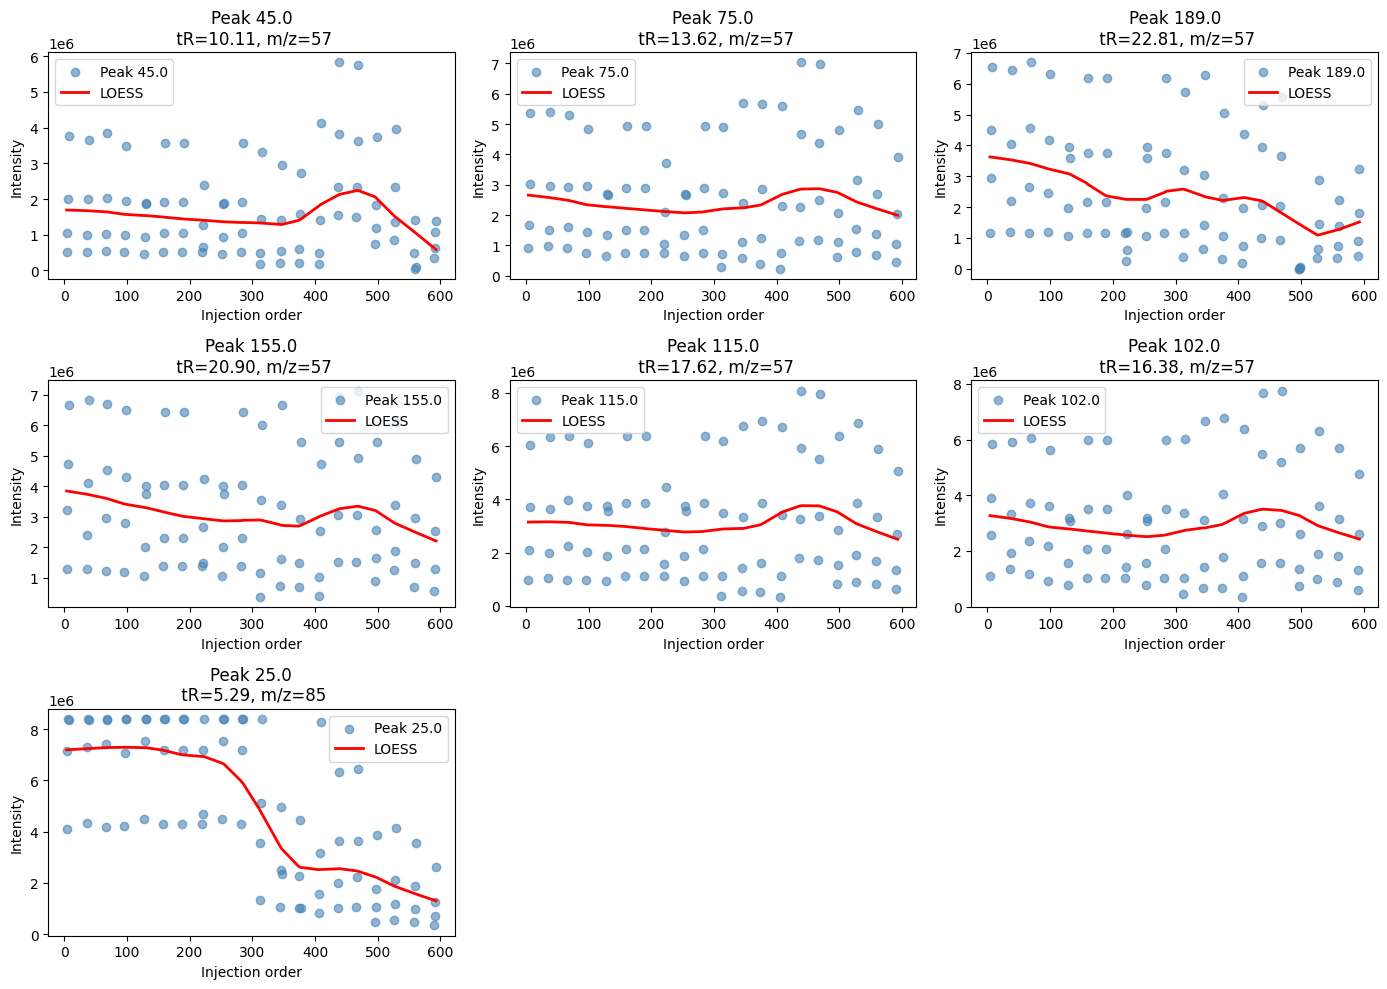

In [48]:

from statsmodels.nonparametric.smoothers_lowess import lowess

stable_ids = stable_peaks["Peak"].unique()

plt.figure(figsize=(14, 10))

for i, peak in enumerate(stable_ids, 1):
    sub = df_qc[df_qc["Peak"] == peak].dropna(
        subset=["Intensity","Injection_order"]
    )
    if sub.empty:
        continue
    
    x = sub["Injection_order"].values
    y = sub["Intensity"].values
    
    # LOESS smooth for visualization only
    loess_fit = lowess(y, x, frac=0.3, return_sorted=True)
    
    plt.subplot(3, 3, i)
    plt.scatter(x, y, alpha=0.6, label=f"Peak {peak}", color="steelblue")
    plt.plot(loess_fit[:,0], loess_fit[:,1], color="red", linewidth=2, label="LOESS")
    
    plt.title(f"Peak {peak}\n tR={sub['tR_best'].iloc[0]:.2f}, m/z={sub['m/z'].iloc[0]}")
    plt.xlabel("Injection order")
    plt.ylabel("Intensity")
    plt.legend()

plt.tight_layout()
plt.show()


Most alkanes are fairly stable, but octane (tR ≈ 5.29 min) is declining too much.

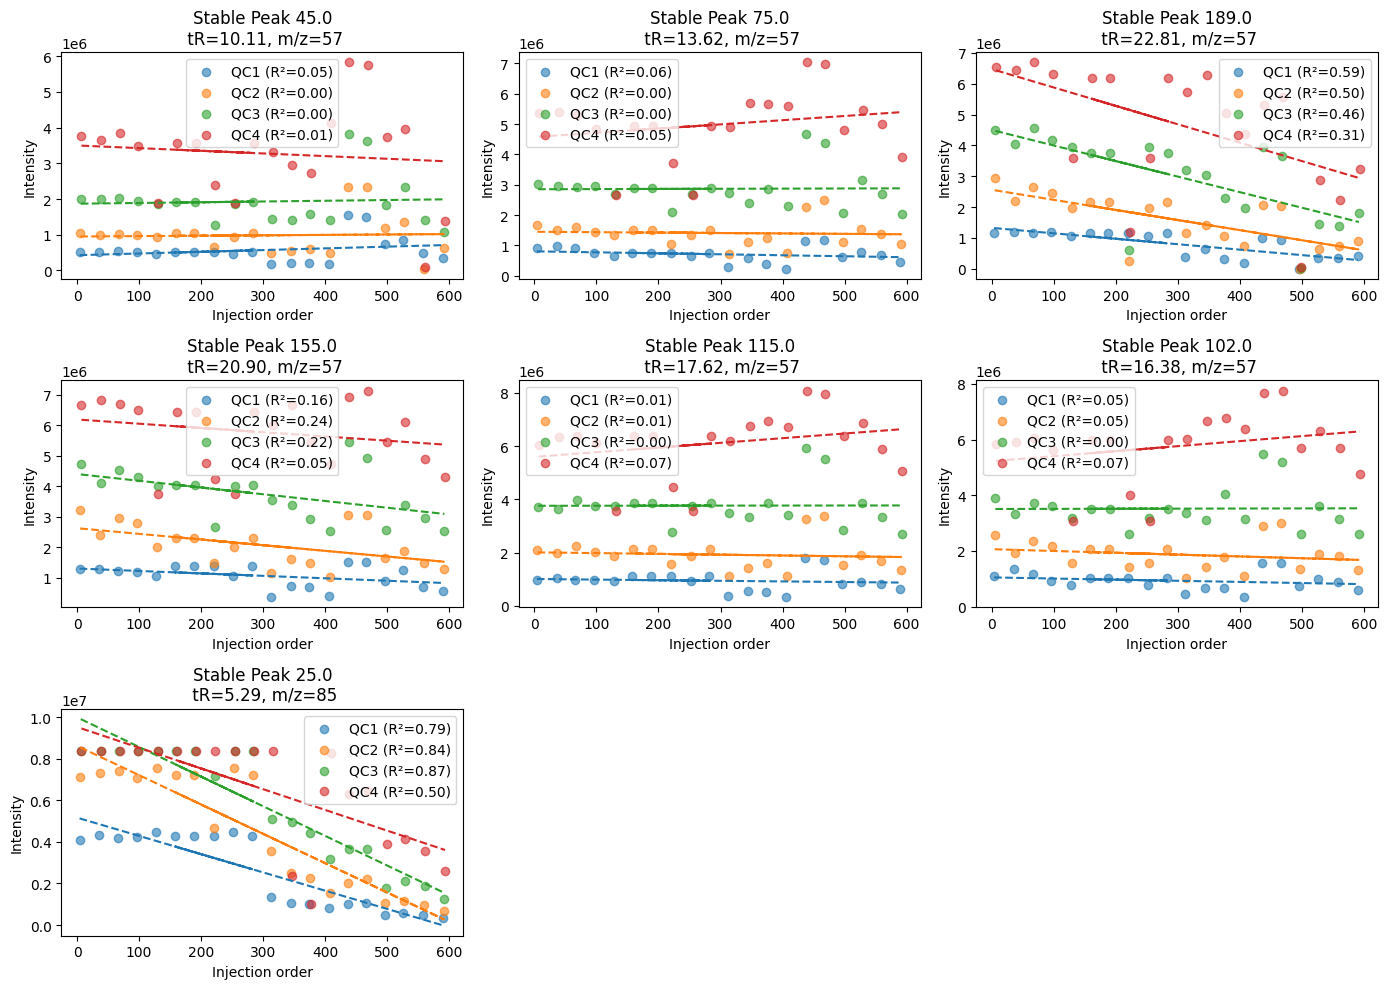

In [49]:
qc_levels = ["QC1", "QC2", "QC3", "QC4"]

plt.figure(figsize=(14, 10))

for i, peak in enumerate(stable_ids, 1):
    sub = df_qc[df_qc["Peak"] == peak].dropna(
        subset=["Intensity","Injection_order"]
    )
    if sub.empty:
        continue
    
    plt.subplot(3, 3, i)
    
    # Separate by QC level
    for qc in qc_levels:
        sub_qc = sub[sub["Sample"].str.startswith(qc)]
        if sub_qc.empty:
            continue

        x = sub_qc["Injection_order"].values
        y = sub_qc["Intensity"].values
        
        # Linear regression for drift check
        if len(sub_qc) > 1:
            model = LinearRegression().fit(x.reshape(-1,1), y)
            y_pred = model.predict(x.reshape(-1,1))
            r2 = model.score(x.reshape(-1,1), y)
        else:
            y_pred = y
            r2 = np.nan

        plt.scatter(x, y, alpha=0.6, label=f"{qc} (R²={r2:.2f})")
        plt.plot(x, y_pred, linestyle="--")

    plt.title(f"Stable Peak {peak}\n tR={sub['tR_best'].iloc[0]:.2f}, m/z={sub['m/z'].iloc[0]}")
    plt.xlabel("Injection order")
    plt.ylabel("Intensity")
    plt.legend()

plt.tight_layout()
plt.show()


the figure shows octane instability across QCs when monitored over days/injections.

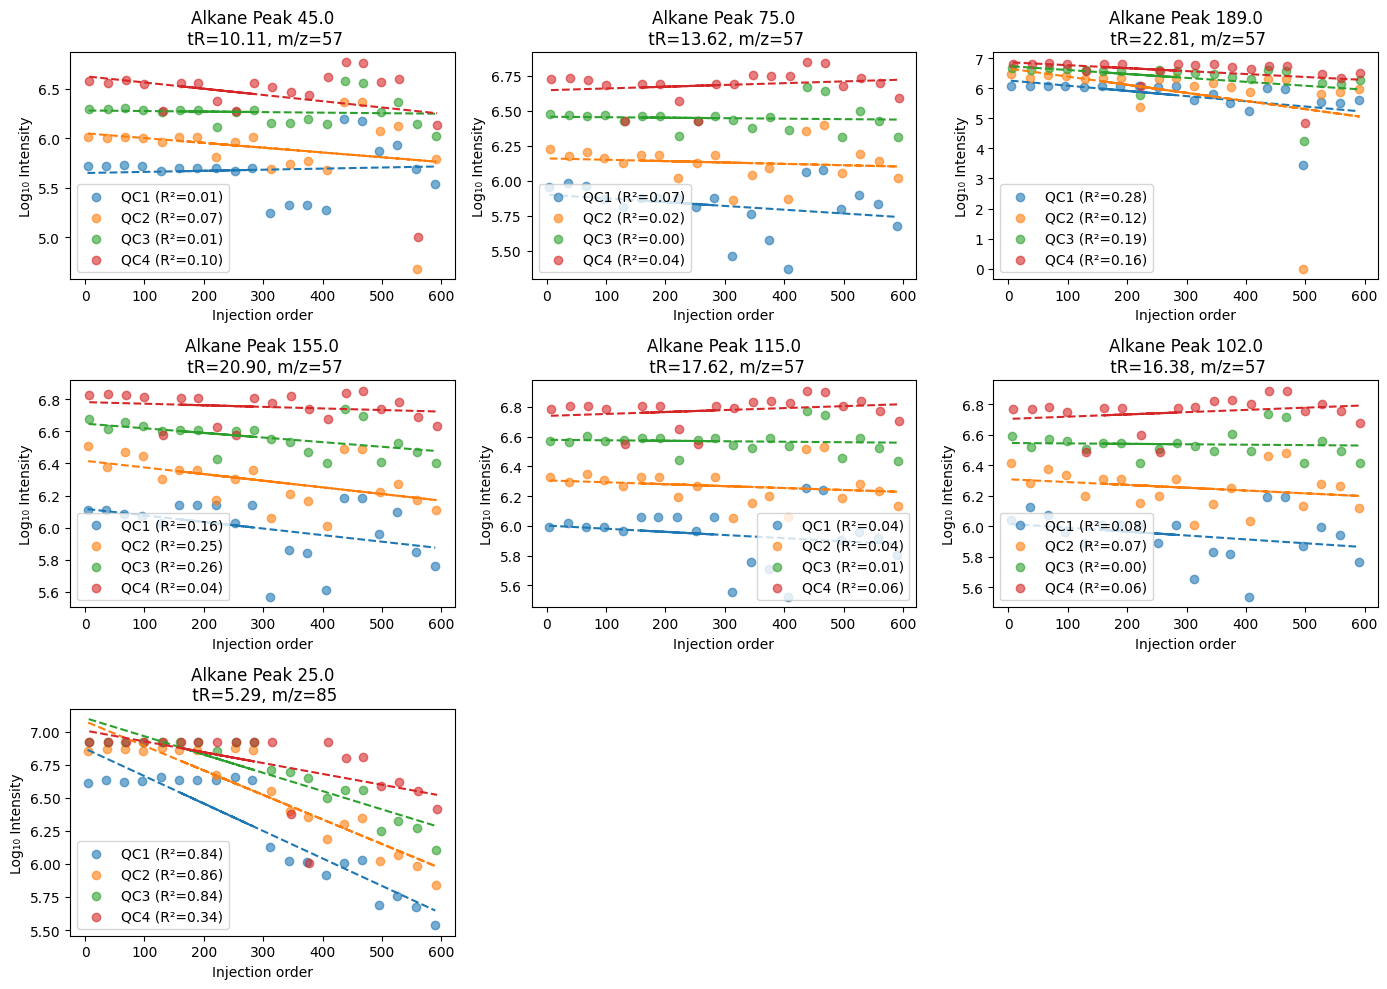

In [50]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

qc_levels = ["QC1", "QC2", "QC3", "QC4"]

# Keep only alkane peaks
alkane_ids = stable_peaks["Peak"].unique()
alkan_qc = df_qc[df_qc["Peak"].isin(alkane_ids)].copy()

# Apply log10 transformation to intensity
alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"] + 1)  # +1 to avoid log(0)

# Plot
plt.figure(figsize=(14, 10))

for i, peak in enumerate(alkane_ids, 1):
    sub = alkan_qc[alkan_qc["Peak"] == peak].dropna(subset=["Log_Intensity","Injection_order"]).copy()
    if sub.empty:
        continue
    
    plt.subplot(3, 3, i)
    
    for qc in qc_levels:
        sub_qc = sub[sub["Sample"].str.startswith(qc)].copy()
        if sub_qc.empty:
            continue

        x = sub_qc["Injection_order"].values
        y = sub_qc["Log_Intensity"].values

        if len(sub_qc) > 1:
            model = LinearRegression().fit(x.reshape(-1,1), y)
            y_pred = model.predict(x.reshape(-1,1))
            r2 = model.score(x.reshape(-1,1), y)
        else:
            y_pred = y
            r2 = np.nan

        plt.scatter(x, y, alpha=0.6, label=f"{qc} (R²={r2:.2f})")
        plt.plot(x, y_pred, linestyle="--")

    plt.title(f"Alkane Peak {peak}\n tR={sub['tR_best'].iloc[0]:.2f}, m/z={sub['m/z'].iloc[0]}")
    plt.xlabel("Injection order")
    plt.ylabel("Log₁₀ Intensity")
    plt.legend()

plt.tight_layout()
plt.show()


   Peak   QC     Slope        R2
0  45.0  QC1  0.000111  0.006305
1  45.0  QC2 -0.000483  0.065474
2  45.0  QC3 -0.000054  0.005435
3  45.0  QC4 -0.000630  0.096398
4  75.0  QC1 -0.000270  0.073143

Global drift (mean slope across alkanes): -0.0006 log10 intensity per injection


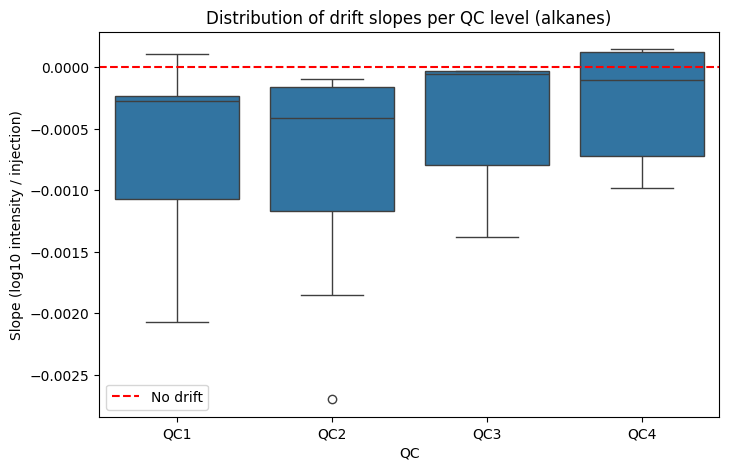

In [51]:
from sklearn.linear_model import LinearRegression
import seaborn as sns

alkan_qc = alkan_qc.copy()
alkan_qc["QC_label"] = alkan_qc["Sample"].str.extract(r"(QC\d+)")

# Log-transform intensities if not already done
if "Log_Intensity" not in alkan_qc.columns:
    alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"])

drift_summary = []

for peak in alkane_ids:
    sub = alkan_qc[alkan_qc["Peak"] == peak].copy()
    for qc in qc_levels:
        sub_qc = sub[sub["QC_label"] == qc].dropna(subset=["Log_Intensity","Injection_order"])
        if len(sub_qc) > 1:
            X = sub_qc["Injection_order"].values.reshape(-1, 1)
            y = sub_qc["Log_Intensity"].values
            model = LinearRegression().fit(X, y)
            slope = model.coef_[0]
            r2 = model.score(X, y)
            drift_summary.append((peak, qc, slope, r2))

# Make DataFrame
drift_df = pd.DataFrame(drift_summary, columns=["Peak","QC","Slope","R2"])

print(drift_df.head())

# Average drift across alkanes
mean_slope = drift_df["Slope"].mean()
print(f"\nGlobal drift (mean slope across alkanes): {mean_slope:.4f} log10 intensity per injection")



plt.figure(figsize=(8,5))
sns.boxplot(x="QC", y="Slope", data=drift_df)
plt.axhline(0, color="red", linestyle="--", label="No drift")
plt.title("Distribution of drift slopes per QC level (alkanes)")
plt.ylabel("Slope (log10 intensity / injection)")
plt.legend()
plt.show()


Across QC levels, alkane signals generally decrease over time, with the strongest drift in QC1–QC3 and improved stability in QC4.

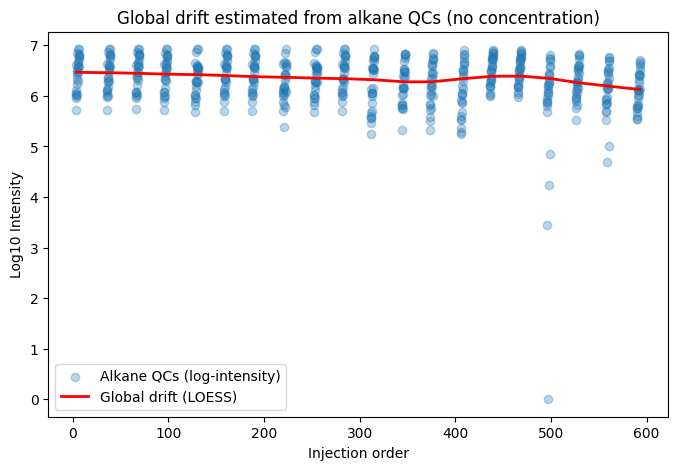

In [52]:
from statsmodels.nonparametric.smoothers_lowess import lowess

#Estimate drift from alkanes

# Keep only alkane peaks (stable peaks)
alkane_ids = stable_peaks["Peak"].unique()
alkan_qc = df_qc[df_qc["Peak"].isin(alkane_ids)].copy()

# Extract QC label
alkan_qc["QC_label"] = alkan_qc["Sample"].str.extract(r"(QC\d+)")

# Log-transform intensities for stability
alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"] + 1)

# Fit LOESS on all alkane QC points (global drift)
x = alkan_qc["Injection_order"].values
y = alkan_qc["Log_Intensity"].values
loess_fit = lowess(y, x, frac=0.3, return_sorted=True)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.3, label="Alkane QCs (log-intensity)")
plt.plot(loess_fit[:,0], loess_fit[:,1], color="red", linewidth=2, label="Global drift (LOESS)")
plt.xlabel("Injection order")
plt.ylabel("Log10 Intensity")
plt.title("Global drift estimated from alkane QCs (no concentration)")
plt.legend()
plt.show()


Global QC drift is minimal across the run, with only a slight decrease in alkane signal intensity and a few outlier injections showing sharp losses

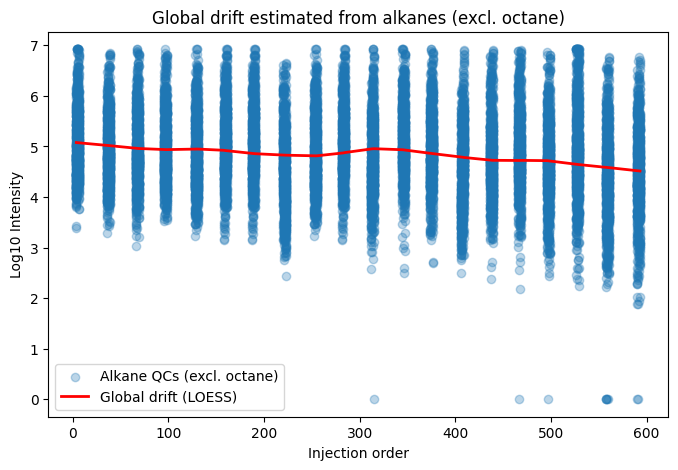

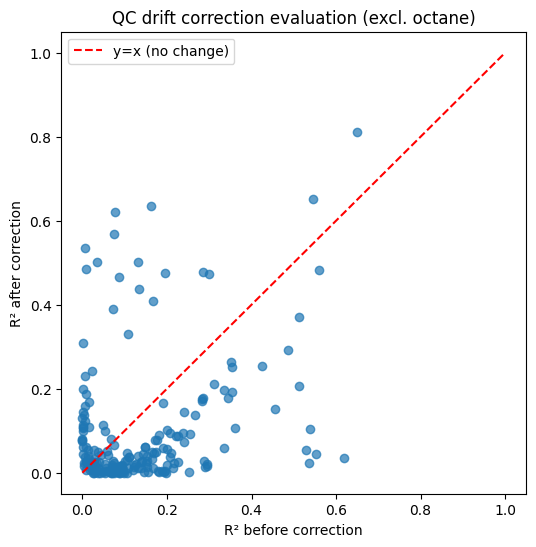

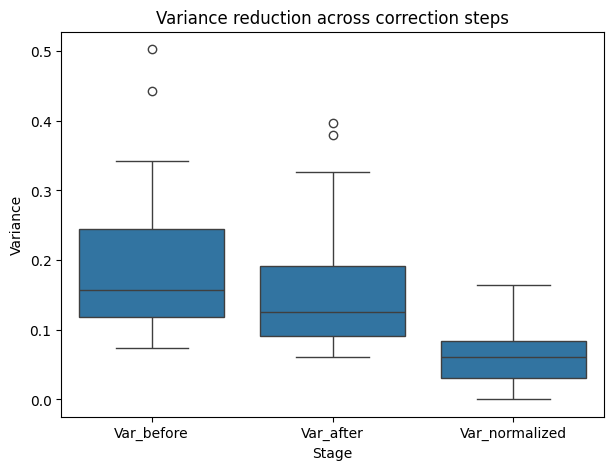

,#,Filename,Sample_x,Block,Plot,Sample_order,Sample_date,Rep,Day,Injection_order,...,ID Rep2,Sample_y,Intensity,Sample_clean,tR_best,SampleCol,Sample,Intensity_corrected,QC_flag,Normalized
0,1152.0,S96_44_B1_D1_T1,NLD;MET;96;64;2024;44;FELSINA,1.0,1.0,1.0,NaN,1.0,1,10,...,NaN,s1 S96_44_B1_D1_T1_Rep1,3756487.0,NLD;MET;96;64;2024;44;FELSINA,NaN,NaN,NaN,2.146516e+06,False,15.117235
1,1153.0,S96_14_B1_D1_T1,NLD;MET;96;64;2024;14;AVARNA,1.0,2.0,2.0,NaN,1.0,1,11,...,NaN,s2 S96_14_B1_D1_T1_Rep1,2936231.0,NLD;MET;96;64;2024;14;AVARNA,NaN,NaN,NaN,1.684594e+06,False,11.864063
2,1154.0,S96_83_B1_D1_T1,NLD;MET;96;64;2024;83;SARPO MIRA,1.0,3.0,3.0,NaN,1.0,1,12,...,NaN,s17 S96_83_B1_D1_T1_Rep1,1388063.0,NLD;MET;96;64;2024;83;SARPO MIRA,NaN,NaN,NaN,7.995892e+05,False,5.631254
3,1155.0,S96_9_B1_D1_T1,NLD;MET;96;64;2024;9;ANTI,1.0,4.0,4.0,NaN,1.0,1,13,...,NaN,s3 S96_9_B1_D1_T1_Rep1,1910915.0,NLD;MET;96;64;2024;9;ANTI,NaN,NaN,NaN,1.105228e+06,False,7.783772
4,1156.0,S96_28_B1_D1_T1,NLD;MET;96;64;2024;28;CHOPIN,1.0,5.0,5.0,NaN,1.0,1,14,...,NaN,s4 S96_28_B1_D1_T1_Rep1,2419738.0,NLD;MET;96;64;2024;28;CHOPIN,NaN,NaN,NaN,1.405179e+06,False,9.896233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11095,1753.0,S96_21_B2_D20_T2,NLD;MET;96;64;2024;21;CAMEL,10.0,9.0,187.0,NaN,2.0,20,611,...,NaN,s171 S96_21_B2_D20_T2_Rep2,32669.0,NLD;MET;96;64;2024;21;CAMEL,NaN,NaN,NaN,6.660976e+04,False,2.139985
11096,1754.0,S96_61_B2_D20_T2,NLD;MET;96;64;2024;61;MEMPHIS,10.0,6.0,184.0,NaN,2.0,20,612,...,NaN,s172 S96_61_B2_D20_T2_Rep2,37405.0,NLD;MET;96;64;2024;61;MEMPHIS,NaN,NaN,NaN,7.626597e+04,False,2.450212
11097,1755.0,S96_67_B2_D20_T2,NLD;MET;96;64;2024;67;NOBLESSE,10.0,7.0,185.0,NaN,2.0,20,613,...,NaN,s173 S96_67_B2_D20_T2_Rep2,48328.0,NLD;MET;96;64;2024;67;NOBLESSE,NaN,NaN,NaN,9.853684e+04,False,3.165713
11098,1756.0,S96_49_B2_D20_T2,NLD;MET;96;64;2024;49;FORTUS,10.0,5.0,183.0,NaN,2.0,20,614,...,NaN,s174 S96_49_B2_D20_T2_Rep2,40667.0,NLD;MET;96;64;2024;49;FORTUS,NaN,NaN,NaN,8.291685e+04,False,2.663886


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression

# ---------------------------
# 1. Estimate drift from QC alkanes (exclude octane, peak 25)
# ---------------------------
alkane_ids = [p for p in df_qc["Peak"].unique() if p != 25]
alkan_qc = df_qc[df_qc["Peak"].isin(alkane_ids)].copy()
alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"] + 1)

x = alkan_qc["Injection_order"].values
y = alkan_qc["Log_Intensity"].values
loess_fit = lowess(y, x, frac=0.3, return_sorted=True)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.3, label="Alkane QCs (excl. octane)")
plt.plot(loess_fit[:,0], loess_fit[:,1], color="red", linewidth=2, label="Global drift (LOESS)")
plt.xlabel("Injection order")
plt.ylabel("Log10 Intensity")
plt.title("Global drift estimated from alkanes (excl. octane)")
plt.legend()
plt.show()

# ---------------------------
# 2. Reshape df_matched to long format
# ---------------------------
meta_cols = ["Peak", "tR", "m/z", "ID Rep1", "ID Rep2"]
sample_cols = [c for c in df_matched.columns if c not in meta_cols]

long_samples = df_matched.melt(
    id_vars=meta_cols,
    value_vars=sample_cols,
    var_name="Sample",
    value_name="Intensity"
)

# Clean sample names
long_samples["Filename"] = (
    long_samples["Sample"]
    .str.replace(r"^s\d+\s*", "", regex=True)
    .str.replace(r"_Rep\d+$", "", regex=True)
)

# Merge with master table
samples_merged = master_table.merge(long_samples, on="Filename", how="inner")

# Unify sample column
if "Sample_x" in samples_merged.columns and "Sample_y" in samples_merged.columns:
    samples_merged["Sample_clean"] = samples_merged["Sample_x"].fillna(samples_merged["Sample_y"])
elif "Sample" in samples_merged.columns:
    samples_merged["Sample_clean"] = samples_merged["Sample"]
else:
    raise ValueError("No Sample column found after merging.")

# ---------------------------
# 3. Apply drift correction
# ---------------------------
all_data = pd.concat([samples_merged, df_qc], ignore_index=True)

corrected_records = []
for peak in all_data["Peak"].unique():
    sub = all_data[all_data["Peak"] == peak].copy()
    drift_factor = np.interp(sub["Injection_order"], loess_fit[:,0], loess_fit[:,1])

    log_intensity = np.log10(sub["Intensity"] + 1)
    log_corrected = log_intensity - (drift_factor - drift_factor.mean())
    sub["Intensity_corrected"] = 10**log_corrected - 1

    corrected_records.append(sub)

df_corrected = pd.concat(corrected_records, ignore_index=True)
df_corrected["QC_flag"] = df_corrected["Sample"].str.contains("QC", na=False)

# ---------------------------
# 4. QC drift evaluation (R²)
# ---------------------------
qc_eval = []
for peak in df_qc["Peak"].unique():
    raw = df_qc[df_qc["Peak"] == peak]
    corr = df_corrected[(df_corrected["Peak"] == peak) & (df_corrected["QC_flag"])]

    if len(raw) > 2 and len(corr) > 2:
        X_raw = raw["Injection_order"].values.reshape(-1, 1)
        y_raw = np.log10(raw["Intensity"].values + 1)
        r2_raw = LinearRegression().fit(X_raw, y_raw).score(X_raw, y_raw)

        X_corr = corr["Injection_order"].values.reshape(-1, 1)
        y_corr = np.log10(corr["Intensity_corrected"].values + 1)
        r2_corr = LinearRegression().fit(X_corr, y_corr).score(X_corr, y_corr)

        qc_eval.append((peak, r2_raw, r2_corr))

qc_eval_df = pd.DataFrame(qc_eval, columns=["Peak","R2_before","R2_after"])

plt.figure(figsize=(6,6))
plt.scatter(qc_eval_df["R2_before"], qc_eval_df["R2_after"], alpha=0.7)
plt.plot([0,1],[0,1],"r--",label="y=x (no change)")
plt.xlabel("R² before correction")
plt.ylabel("R² after correction")
plt.title("QC drift correction evaluation (excl. octane)")
plt.legend()
plt.show()

# ---------------------------
# 5. Biological samples only
# ---------------------------
bio_raw = samples_merged[~samples_merged["Sample_clean"].str.contains("QC", na=False)].copy()
bio_corr = df_corrected[~df_corrected["QC_flag"]].copy()

# ---------------------------
# 6. Variance before and after drift correction
# ---------------------------
bio_eval = []
for peak in bio_raw["Peak"].unique():
    raw_vals = bio_raw[bio_raw["Peak"] == peak]["Intensity"]
    corr_vals = bio_corr[bio_corr["Peak"] == peak]["Intensity_corrected"]

    if len(raw_vals) > 2 and len(corr_vals) > 2:
        var_before = np.var(np.log10(raw_vals.values + 1))
        var_after  = np.var(np.log10(corr_vals.values + 1))
        bio_eval.append((peak, var_before, var_after))

bio_eval_df = pd.DataFrame(bio_eval, columns=["Peak","Var_before","Var_after"])

# ---------------------------
# 7. QC3-based normalization (biological samples only)
# ---------------------------
qc3_vals = df_corrected[(df_corrected["QC_flag"]) & (df_corrected["Sample"].str.contains("QC3"))]

bio_norm_records = []
for peak in bio_corr["Peak"].unique():
    sub = bio_corr[bio_corr["Peak"] == peak].copy()
    qc3_peak = qc3_vals[qc3_vals["Peak"] == peak]["Intensity_corrected"].mean()

    if qc3_peak > 0:
        sub["Normalized"] = sub["Intensity_corrected"] / qc3_peak
        bio_norm_records.append(sub)

df_normalized = pd.concat(bio_norm_records, ignore_index=True)

bio_eval_norm = []
for peak in df_normalized["Peak"].unique():
    vals = df_normalized[df_normalized["Peak"] == peak]["Normalized"]
    if len(vals) > 2:
        var_norm = np.var(np.log10(vals.values + 1))
        bio_eval_norm.append((peak, var_norm))

bio_eval_norm_df = pd.DataFrame(bio_eval_norm, columns=["Peak","Var_normalized"])

# ---------------------------
# 8. Combine and visualize
# ---------------------------
combined = bio_eval_df.merge(bio_eval_norm_df, on="Peak", how="inner")

plt.figure(figsize=(7,5))
sns.boxplot(
    data=pd.melt(combined, id_vars="Peak", var_name="Stage", value_name="Variance"),
    x="Stage", y="Variance"
)
plt.title("Variance reduction across correction steps")
plt.show()
df_normalized 

In [112]:
df_norm = df_normalized.copy()

# Extract core ID from Filename (before _B1 or _B2)
df_norm["Sample_core"] = df_norm["Filename"].str.extract(r"(S\d+_\d+)_B\d")

# Assign Rep based on B1 / B2
df_norm["Rep"] = np.where(
    df_norm["Filename"].str.contains("_B1"), "Rep1",
    np.where(df_norm["Filename"].str.contains("_B2"), "Rep2", "Other")
)

print(df_norm[["Filename","Sample_core","Rep"]].head(10))


          Filename Sample_core   Rep
0  S96_44_B1_D1_T1      S96_44  Rep1
1  S96_14_B1_D1_T1      S96_14  Rep1
2  S96_83_B1_D1_T1      S96_83  Rep1
3   S96_9_B1_D1_T1       S96_9  Rep1
4  S96_28_B1_D1_T1      S96_28  Rep1
5  S96_92_B1_D1_T1      S96_92  Rep1
6  S96_21_B1_D1_T1      S96_21  Rep1
7   S96_7_B1_D1_T1       S96_7  Rep1
8  S96_53_B1_D1_T1      S96_53  Rep1
9  S96_55_B1_D1_T1      S96_55  Rep1


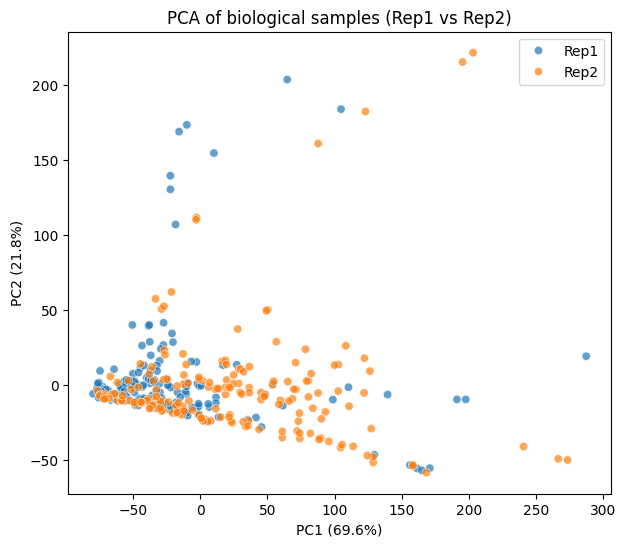

In [113]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1. Keep only sample rows (exclude QC)
# -------------------------------------------------
df_samples = df_norm[~df_norm["QC_flag"]].copy()

# -------------------------------------------------
# 2. Clean replicate labels
# -------------------------------------------------
# Extract core sample name (without Rep1/Rep2)
df_samples["Sample_core"] = df_samples["Sample_y"].str.replace(r"_Rep[12]$", "", regex=True)

# Extract replicate tag
df_samples["Rep"] = df_samples["Sample_y"].str.extract(r"(Rep\d+)$")

# -------------------------------------------------
# 3. Pivot: rows = Sample_y, columns = Peak, values = Normalized
# -------------------------------------------------
data_matrix = df_samples.pivot_table(
    index="Sample_y", 
    columns="Peak", 
    values="Normalized", 
    aggfunc="mean"
).fillna(0)

# -------------------------------------------------
# 4. PCA
# -------------------------------------------------
pca = PCA(n_components=2)
scores = pca.fit_transform(data_matrix.values)

# -------------------------------------------------
# 5. Plot Rep1 vs Rep2 in PCA space
# -------------------------------------------------
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=scores[:,0], y=scores[:,1],
    hue=df_samples.drop_duplicates("Sample_y")["Rep"],  # color by Rep1/Rep2
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of biological samples (Rep1 vs Rep2)")
plt.legend()
plt.show()


Wide matrix shape: (370, 30)
                                   PC1         PC2            Sample_core  \
Sample_y                                                                    
s1 S96_44_B1_D1_T1_Rep1      64.796641  203.529060     s1 S96_44_B1_D1_T1   
s1 S96_51_B2_D11_T1_Rep2    -68.792603   -8.202062    s1 S96_51_B2_D11_T1   
s10 S96_55_B1_D1_T2_Rep1     48.604611   -6.392712    s10 S96_55_B1_D1_T2   
s10 S96_59_B2_D11_T2_Rep2   -68.564818   -9.052973   s10 S96_59_B2_D11_T2   
s100 S96_76_B2_D16_T2_Rep2  170.847282  -55.593666  s100 S96_76_B2_D16_T2   

                             Rep  
Sample_y                          
s1 S96_44_B1_D1_T1_Rep1     Rep1  
s1 S96_51_B2_D11_T1_Rep2    Rep2  
s10 S96_55_B1_D1_T2_Rep1    Rep1  
s10 S96_59_B2_D11_T2_Rep2   Rep2  
s100 S96_76_B2_D16_T2_Rep2  Rep2  
⚠️ No Rep1–Rep2 pairs found for PCA distance.
⚠️ No overlapping Rep1–Rep2 found for correlation.


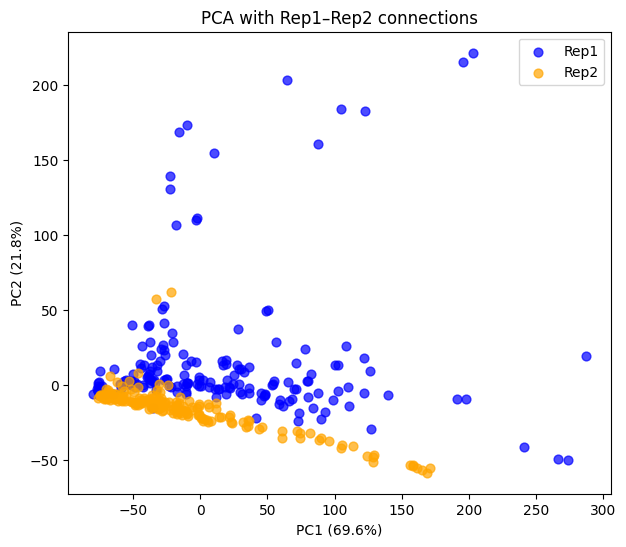

In [114]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.distance import euclidean
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Build a "Sample_core" column (remove Rep suffix)
# ---------------------------------------------------
df_normalized = df_norm.copy()
df_normalized["Sample_core"] = (
    df_normalized["Sample_y"]
    .str.replace("_Rep1", "", regex=False)
    .str.replace("_Rep2", "", regex=False)
)

# ---------------------------------------------------
# 2. Pivot to wide format: samples x peaks
# ---------------------------------------------------
wide = df_normalized.pivot_table(
    index="Sample_y",    # each replicate is a row
    columns="Peak",
    values="Normalized"
).fillna(0)

print("Wide matrix shape:", wide.shape)

# ---------------------------------------------------
# 3. Run PCA on normalized intensities
# ---------------------------------------------------
pca = PCA(n_components=2)
coords = pca.fit_transform(wide.values)

# Store PCA coords with sample names
sample_coords = pd.DataFrame(coords, columns=["PC1", "PC2"], index=wide.index)

# Add core + replicate info
sample_coords["Sample_core"] = sample_coords.index.str.replace("_Rep1","",regex=False).str.replace("_Rep2","",regex=False)
sample_coords["Rep"] = np.where(sample_coords.index.str.contains("_Rep1"), "Rep1", "Rep2")

print(sample_coords.head())

# ---------------------------------------------------
# 4. Compute PCA distances between Rep1–Rep2
# ---------------------------------------------------
distances = []
for core, group in sample_coords.groupby("Sample_core"):
    if group["Rep"].nunique() == 2:  # both Rep1 + Rep2 exist
        p1 = group.loc[group["Rep"]=="Rep1", ["PC1","PC2"]].values[0]
        p2 = group.loc[group["Rep"]=="Rep2", ["PC1","PC2"]].values[0]
        distances.append(euclidean(p1,p2))

if distances:
    print("Mean Rep1–Rep2 PCA distance:", np.mean(distances))
else:
    print("⚠️ No Rep1–Rep2 pairs found for PCA distance.")

# ---------------------------------------------------
# 5. Correlation of normalized intensities between replicates
# ---------------------------------------------------
correlations = []
for core in df_normalized["Sample_core"].unique():
    rep1 = df_normalized.query("Sample_core == @core and Sample_y.str.contains('Rep1')")["Normalized"]
    rep2 = df_normalized.query("Sample_core == @core and Sample_y.str.contains('Rep2')")["Normalized"]
    if not rep1.empty and not rep2.empty:
        r, _ = pearsonr(rep1, rep2)
        correlations.append(r)

if correlations:
    print("Mean Rep1–Rep2 intensity correlation:", np.mean(correlations))
else:
    print("⚠️ No overlapping Rep1–Rep2 found for correlation.")

# ---------------------------------------------------
# 6. Plot PCA scatter with Rep1–Rep2 connections
# ---------------------------------------------------
plt.figure(figsize=(7,6))
colors = {"Rep1":"blue","Rep2":"orange"}

for core, group in sample_coords.groupby("Sample_core"):
    if group["Rep"].nunique() == 2:
        plt.plot(group["PC1"], group["PC2"], "k-", alpha=0.3)

for rep, group in sample_coords.groupby("Rep"):
    plt.scatter(group["PC1"], group["PC2"], label=rep, s=40, alpha=0.7, c=colors[rep])

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA with Rep1–Rep2 connections")
plt.legend()
plt.show()


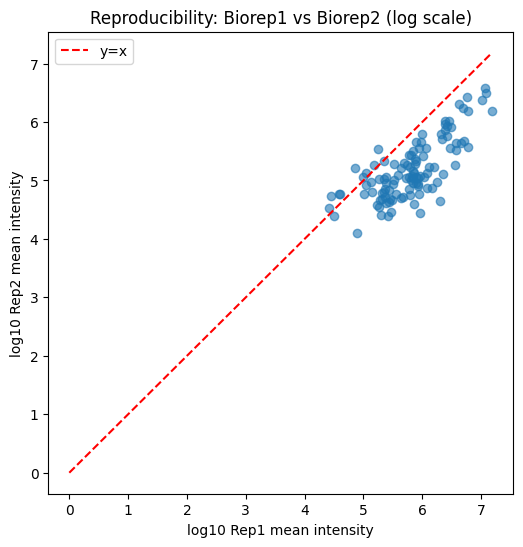

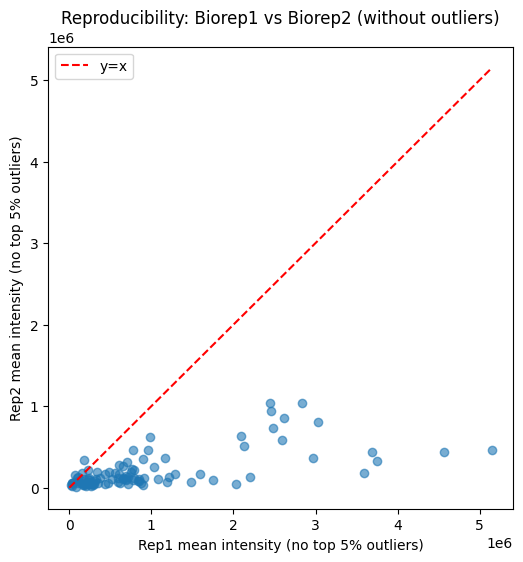

In [80]:


# Rep1 and Rep2 mean intensities (from your previous calculation)
rep1_mean = df_matched[rep1_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
rep2_mean = df_matched[rep2_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# --- Scatter with log scale ---
plt.figure(figsize=(6,6))
plt.scatter(np.log10(rep1_mean+1), np.log10(rep2_mean+1), alpha=0.6)
max_val = max(np.log10(rep1_mean.max()+1), np.log10(rep2_mean.max()+1))
plt.plot([0, max_val], [0, max_val], "r--", label="y=x")
plt.xlabel("log10 Rep1 mean intensity")
plt.ylabel("log10 Rep2 mean intensity")
plt.title("Reproducibility: Biorep1 vs Biorep2 (log scale)")
plt.legend()
plt.show()

# --- Scatter without outliers (remove top 5%) ---
threshold1 = np.percentile(rep1_mean, 95)
threshold2 = np.percentile(rep2_mean, 95)

mask = (rep1_mean < threshold1) & (rep2_mean < threshold2)

plt.figure(figsize=(6,6))
plt.scatter(rep1_mean[mask], rep2_mean[mask], alpha=0.6)
max_val = max(rep1_mean[mask].max(), rep2_mean[mask].max())
plt.plot([0, max_val], [0, max_val], "r--", label="y=x")
plt.xlabel("Rep1 mean intensity (no top 5% outliers)")
plt.ylabel("Rep2 mean intensity (no top 5% outliers)")
plt.title("Reproducibility: Biorep1 vs Biorep2 (without outliers)")
plt.legend()
plt.show()


In [63]:

from scipy.stats import pearsonr


# ------------------------------
# 1. Extract Rep1 and Rep2 columns
# ------------------------------
rep1_cols = [c for c in df_matched.columns if "Rep1" in c]
rep2_cols = [c for c in df_matched.columns if "Rep2" in c]

# Mean intensities per peak
rep1_mean = df_matched[rep1_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
rep2_mean = df_matched[rep2_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# ------------------------------
# 2. Pearson correlation (raw + log)
# ------------------------------
# Raw
corr_raw, _ = pearsonr(rep1_mean, rep2_mean)

# Log10 (avoid zeros by adding 1)
rep1_log = np.log10(rep1_mean + 1)
rep2_log = np.log10(rep2_mean + 1)
corr_log, _ = pearsonr(rep1_log, rep2_log)

print(f"Global Pearson correlation (raw): {corr_raw:.3f}")
print(f"Global Pearson correlation (log10): {corr_log:.3f}")



Global Pearson correlation (raw): 0.834
Global Pearson correlation (log10): 0.755


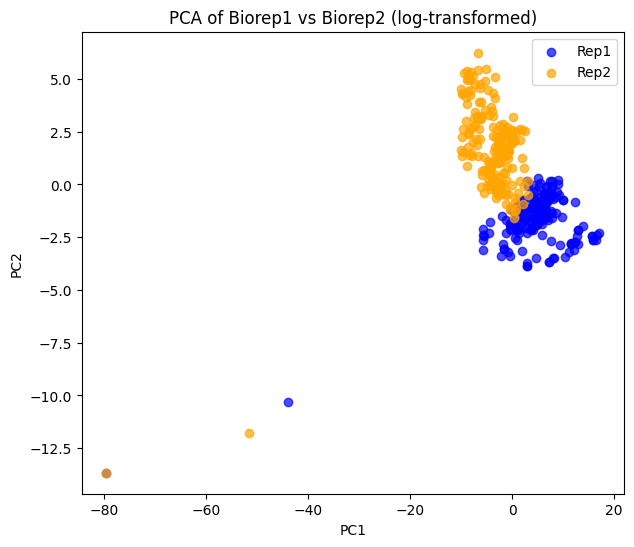

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Collect replicate columns
rep1_cols = [c for c in df_matched.columns if "Rep1" in c]
rep2_cols = [c for c in df_matched.columns if "Rep2" in c]

# --- Build feature matrix (samples × peaks)
rep1_data = df_matched[rep1_cols].T
rep2_data = df_matched[rep2_cols].T

# Combine into one matrix
X = pd.concat([rep1_data, rep2_data], axis=0)

# --- Log transform (add +1 to avoid log(0))
X = np.log10(X + 1)

# --- Handle missing values (important!)
X = X.fillna(0)   # Option 1: fill missing with 0
# X = X.dropna(axis=1)  # Option 2: drop peaks with NaN

# --- Scale data
X_scaled = StandardScaler().fit_transform(X)

# --- PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)

# Labels
labels = (["Rep1"] * len(rep1_data)) + (["Rep2"] * len(rep2_data))

# --- Plot PCA
plt.figure(figsize=(7,6))
for rep, color in zip(["Rep1","Rep2"], ["blue","orange"]):
    idx = [i for i, r in enumerate(labels) if r == rep]
    plt.scatter(scores[idx,0], scores[idx,1], c=color, label=rep, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Biorep1 vs Biorep2 (log-transformed)")
plt.legend()
plt.show()


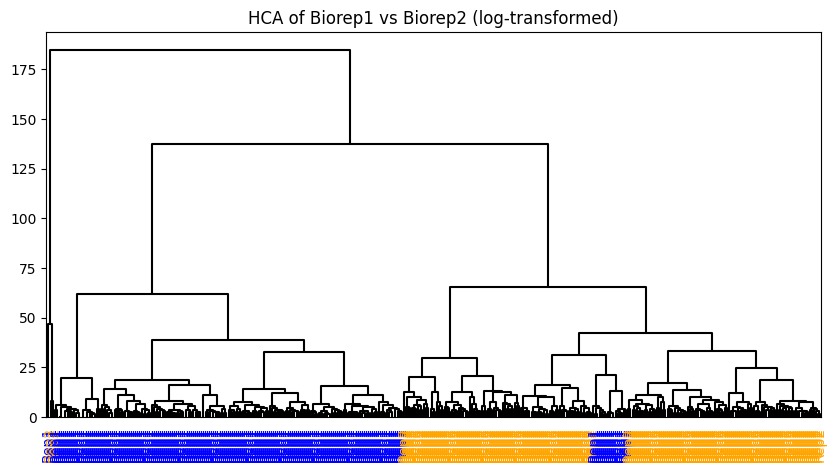

In [67]:
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns

# --- Use same log-transformed, scaled data
Z = linkage(X_scaled, method="ward")

# --- Make labels with Rep1/Rep2 info
labels = (["Rep1"] * len(rep1_data)) + (["Rep2"] * len(rep2_data))

# --- Assign colors
label_colors = {"Rep1": "blue", "Rep2": "orange"}

plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    labels=labels,
    leaf_rotation=90,
    leaf_font_size=10,
    link_color_func=lambda k: 'black'
)

# Color leaf labels manually
ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl in xlbls:
    lbl.set_color(label_colors[lbl.get_text()])

plt.title("HCA of Biorep1 vs Biorep2 (log-transformed)")
plt.show()
